## AULA DE KNN - seguindo o .pdf 9

### 1. Importando as Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

### 2. Carregando os Dados do Dataset

In [6]:
dataset = np.loadtxt("tumores.csv", delimiter=',', skiprows=2)

X_train = dataset[:, :2]

y_train = dataset[:, 2].astype(int)

print("Amostra das características (X_train):")
print(X_train[:5])
print("\nAmostra dos rótulos (y_train):")
print(y_train[:5])

Amostra das características (X_train):
[[1.9 2.5]
 [3.  3.9]
 [3.5 2.9]
 [2.2 2.2]
 [4.  4.5]]

Amostra dos rótulos (y_train):
[0 0 0 0 0]


### 3. Visualização dos Dados de treinamento

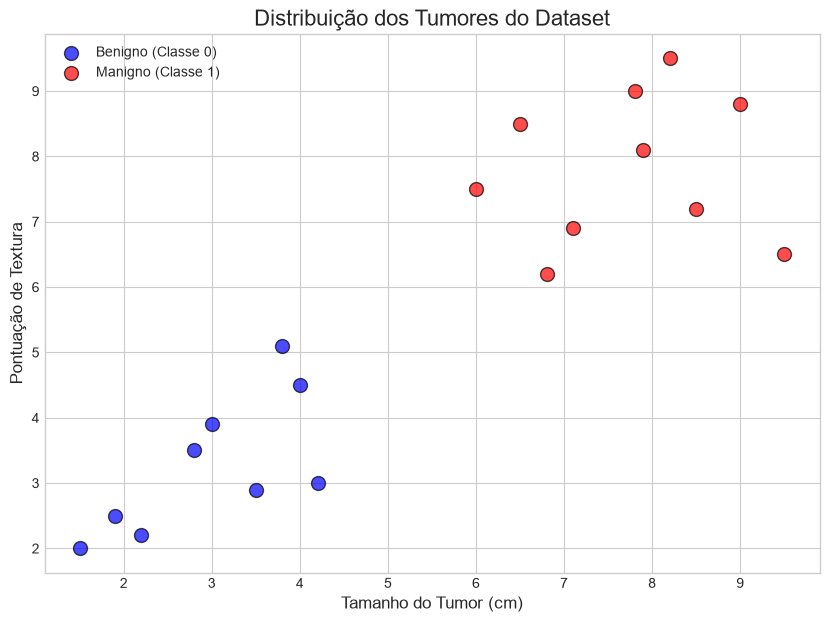

In [10]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 7))


ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
           c='blue', s=100, edgecolors='k', alpha=0.7, label='Benigno (Classe 0)')


ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c='red', s=100, edgecolors='k', alpha=0.7, label='Manigno (Classe 1)')

ax.set_title('Distribuição dos Tumores do Dataset', fontsize=16)
ax.set_xlabel('Tamanho do Tumor (cm)', fontsize=12)
ax.set_ylabel('Pontuação de Textura', fontsize=12)
ax.legend()
plt.show()

### 4. Função da Distância Euclidiana.

In [3]:
def calcular_distancia_euclidiana(ponto1, ponto2):
    """Calcular a distância euclidiana entre dois pontos."""
    return np.sqrt(np.sum((ponto1 - ponto2)**2))

def encontrar_vizinhos(X_train, y_train, ponto_teste, k):
    """Encontra os k vizinhos maispróximos de um ponto de teste."""
    distancias = []

    for i, ponto_treino in enumerate(X_train):
        dist = calcular_distancia_euclidiana(ponto_treino, ponto_teste)
        distancias.append((dist, y_train[i]))

    distancias.sort(key=lambda x: x[0])

    vizinhos = [distancia[1] for distancia in distancias[:k]]
    return vizinhos

def prever_classificacao(vizinhos):
    """Faz a previsão com base no voto majoritário dos vizinhos."""

    contagem_votos = Counter(vizinhos)

    previsao = contagem_votos.most_common(1)[0][0]
    return previsao

### 5. Realizando Previsões

In [4]:
novo_tumor = np.array([5.5, 6.0])
k = 5

vizinhos_proximos = encontrar_vizinhos(X_train, y_train, novo_tumor, k)
previsao_final = prever_classificacao(vizinhos_proximos)

resultado_texto = "Benigno" if previsao_final == 0 else "Maligno"

print(f"O novo tumor tem as características: {novo_tumor}")
print(f"O valor de 'k' escolhido foi: {k}")
print(f"As classes dos vizinhos mais próximos são: {vizinhos_proximos}")
print("------------------------------------------------------------------")
print(f"--> Previsão final: O novo tumor é classificado como {resultado_texto} (Classe {previsao_final})")

NameError: name 'X_train' is not defined